In [21]:
from scipy.io import loadmat
from pandas import Series
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from groupyr import LogisticSGL

In [22]:
# 加载数据
yale = loadmat('data_aug.mat')
#载入YALE32mat文件的方法，得到的x是一个字典，可以print一下他的shape看一下里面的属性
X = yale['data']

y = yale['labels'].T.flatten()     #将数据展开

In [23]:
# 分组
matrix = np.arange(1024).reshape((32, 32))
n = 8    # 矩阵每行分成几份
Groups = []
m1 = np.split(matrix, n, axis=0)
for m in m1:
    group = np.split(m, n, axis=1)
    Groups = Groups + group

for i in range(len(Groups)):
    Groups[i] = Groups[i].flatten()

In [24]:
model = LogisticSGL(
    groups=Groups, l1_ratio=0.04, alpha=0.025).fit(X, y)

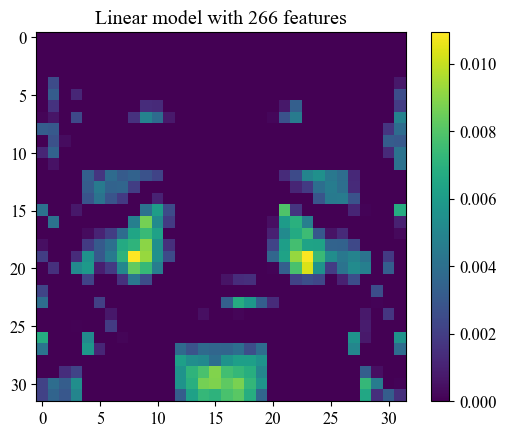

In [25]:
# 输出特征选择结果
from matplotlib import rcParams
importances = abs(model.coef_) / np.sum(abs(model.coef_))
num = np.count_nonzero(importances)
config = {
    "font.family": 'Times New Roman',
    "font.size": 12
}
rcParams.update(config)
plt.clf()
plt.title(f"Linear model with {num} features")

img = (importances).reshape(32, 32).T
plt.imshow(img)
plt.colorbar()
plt.savefig("figures/yale_sgl_selected.pdf", bbox_inches='tight')
plt.show()